# Risikoampel Kombiniert — eine indikatorübergreifende Risikoampel für vier Aktienindices

Ziel dieses Notebooks ist eine einzige, verständliche Kennzahl pro Handelstag: eine
**Ampel** (Grün / Gelb / Rot), die anzeigt, wie belastet die Marktlage gerade ist. Die
Ampel wird aus mehreren technischen Signalen berechnet, die in der Risikoampeltabelle
des Projekts vorgegeben sind — gleitende Durchschnitte (SMA20/100/200) und Marktbreite
(Anteil der Indexmitglieder über ihrem eigenen SMA). Volatilitätsindices und die
Put/Call-Ratio fließen hier bewusst **nicht** ein, da sie nicht Teil dieser Tabelle sind.

Die Ampel wird für vier Indices berechnet: **S&P 500, Dow Jones, NASDAQ 100 und
Russell 2000**. Wichtig für die Aussagekraft der Ampel: Es wird **eine einzige**
Kombination aus Signalen und Schwellenwerten gesucht, die für **alle vier Indices
gleichermaßen** gilt. Es wird also nicht für jeden Index einzeln die jeweils beste
Lösung gesucht — das würde die Ampel zu vier unterschiedlichen Systemen machen, die
sich nur zufällig an die Vergangenheit jedes einzelnen Index anpassen ("Cherry-
Picking"), ohne dass sich daraus eine verlässliche, allgemeingültige Regel ableiten
ließe. Stattdessen wird die Kombination gewählt, die **in jedem der vier Indices**
robust funktioniert — geprüft anhand der historischen Kursverläufe seit 2007 (bzw.
seit 2013 beim Russell 2000, da für diesen Index erst ab diesem Jahr Marktbreite-
Daten vorliegen).

Der Aufbau des Notebooks folgt diesen Schritten: Zunächst werden die benötigten
Kurs- und Marktbreite-Daten geladen (Abschnitt 1) und ein paar wiederverwendbare
Hilfsfunktionen definiert (Abschnitt 2). Abschnitt 3 erklärt die Methodik im Detail.
Abschnitt 4 führt die eigentliche Suche nach der einen gemeinsamen Ampel-Kombination
durch und wendet sie anschließend auf jeden der vier Indices an. Abschnitt 5
vergleicht die vier Indices direkt miteinander, Abschnitt 6 exportiert die Ergebnisse
für das nachfolgende Notebook `Einstiegssignale.ipynb`, und Abschnitt 7 fasst die
wichtigsten Erkenntnisse zusammen.

## 1. Datenbezug und Aufbereitung

### 1.1 Verwendete Bibliotheken

In [1]:
%matplotlib inline
# Numerik, Tabellenverarbeitung und Pfadhandling
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from itertools import combinations

# Statistische Tests (t-Test, Mann-Whitney-U) für die Ampel-Validierung
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display

# Kursdatenbezug über die inoffizielle Yahoo-Finance-Schnittstelle
import yfinance as yf

# Einheitliche Farbpalette (identisch zu den übrigen Notebooks des Projekts, damit
# Grün/Gelb/Rot und die Kurslinien in allen Abbildungen gleich aussehen)
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"
AMPEL_FARBEN = ["Grün", "Gelb", "Rot"]
AMPEL_FARBCODES = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")

Bibliotheken geladen.


**Was wurde hier gemacht?** Alle Programm-Bibliotheken geladen, die im Notebook
gebraucht werden (Datenverarbeitung mit `pandas`/`numpy`, Kursdatenbezug über
`yfinance`, Statistik über `scipy`, Diagramme über `matplotlib`), sowie eine
einheitliche Farbpalette festgelegt. Die Farben sorgen dafür, dass in allen
Abbildungen dieses Notebooks Grün, Gelb und Rot immer dieselbe Bedeutung
(entspannt / angespannt / belastet) und denselben Farbton haben.

### 1.2 Konfiguration

In [2]:
# Vier zu untersuchende Indices mit Yahoo-Finance-Ticker und den Pfaden zu den
# lokal vorliegenden Marktbreite-Rohdaten (TradingView-Exporte,
# wiederverwendet aus Breitenindikatoren/Rohdaten).
INDICES = {
    "SP500": {
        "name": "S&P 500",
        "ticker": "^GSPC",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/S&P500 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/S&P 500 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/S&P 500 200 SMA 19901015 - 20260804.csv"),
        },
    },
    "DowJones": {
        "name": "Dow Jones",
        "ticker": "^DJI",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/Dow Jones 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/Dow Jones 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/Dow Jones 200 SMA 20061229 - 20260804.csv"),
        },
    },
    "NASDAQ100": {
        "name": "NASDAQ 100",
        "ticker": "^NDX",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 200 SMA 20061229 - 20260804.csv"),
        },
    },
    "Russell2000": {
        "name": "Russell 2000",
        "ticker": "^RUT",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/Russell 2000 20 SMA 20131014 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/Russell 2000 50 SMA 20131014 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/Russell 2000 200 SMA 20131014 - 20260804.csv"),
        },
    },
}

START_DATE_DOWNLOAD = "1900-01-01"
START_DATE_ANALYSE  = "2007-01-01"

SMA_WINDOWS_DAILY = [20, 100, 200]
BREADTH_WINDOWS   = [20, 50, 200]
HORIZONS          = [30, 60, 90]

# Kandidaten-Ampelsignale (H1/H2 je SMA-Fenster, H3 Death-Cross-Regime,
# H5 Drawdown-Stufe, B1 je Breite-Fenster) - insgesamt bis zu 11 Kandidaten.
KANDIDATEN_NAMEN = (
    [f"H1_{w}" for w in SMA_WINDOWS_DAILY]
    + [f"H2_{w}" for w in SMA_WINDOWS_DAILY]
    + ["H3_20_200", "H5_Drawdown"]
    + [f"B1_{w}" for w in BREADTH_WINDOWS]
)

# Suchraster der Ampel-Schwellen (gruen_max, rot_min) auf den Belastungsgrad
# (Anteil "schlechter" Signale unter den gewählten Kandidaten, 0..1).
SCHWELLEN_GRID = [
    (0.0, 1.0), (0.0, 0.9), (0.0, 0.8), (0.0, 0.75), (0.0, 0.67), (0.0, 0.6), (0.0, 0.5),
    (0.1, 0.9), (0.15, 0.85), (0.2, 0.8), (0.25, 0.75), (0.3, 0.7),
]

# Zulässiger Anteil Rot-Tage der gewählten Kombination - verhindert die
# entartete Lösung "immer Rot" (Drawdown 0, aber ohne jeden Aussagewert).
MIN_ANTEIL_ROT, MAX_ANTEIL_ROT = 0.05, 0.50
MIN_VALIDE_TAGE = 250  # mind. ca. ein Handelsjahr Grundlage je Kombination

EXPORT_DIR = Path("Hypothesenanalysen_Kombiniert")
EXPORT_DIR.mkdir(exist_ok=True)

print("Indices:", list(INDICES.keys()))
print("Kandidatensignale:", KANDIDATEN_NAMEN)
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")

Indices: ['SP500', 'DowJones', 'NASDAQ100', 'Russell2000']
Kandidatensignale: ['H1_20', 'H1_100', 'H1_200', 'H2_20', 'H2_100', 'H2_200', 'H3_20_200', 'H5_Drawdown', 'B1_20', 'B1_50', 'B1_200']
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt\Projektzusammenführung\Risikoampel Kombiniert\Hypothesenanalysen_Kombiniert


**Was wurde hier gemacht?** Alle festen Rahmenwerte des Notebooks an einer Stelle
gesammelt: welche vier Indices untersucht werden, ab welchem Datum (2007, weil ab
hier für alle Indices durchgehend Marktbreite-Daten vorliegen — außer beim
Russell 2000, siehe Abschnitt 4), welche elf Kandidatensignale zur Auswahl stehen
(erklärt in Abschnitt 3), welche Schwellenwert-Paare für die Ampel getestet werden,
und welche Mindestanforderungen eine Kombination erfüllen muss, damit sie überhaupt
in Frage kommt (mindestens 5 %, höchstens 50 % Rot-Tage — sonst wäre die Ampel
entweder nutzlos selten oder nutzlos häufig aktiv).

### 1.3 Kurs- und Marktbreite-Datenbezug (Ladefunktionen)

In [3]:
def lade_index_daten(ticker: str, start: str) -> pd.DataFrame:
    '''Lädt Tages-OHLCV-Daten von Yahoo Finance.'''
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)
    if raw.empty:
        raise ValueError(f"Keine Daten für '{ticker}' erhalten - Internetverbindung prüfen.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    return raw


def bereinige_daten(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    df_clean = df_clean[~df_clean.index.duplicated(keep="first")].sort_index()
    letzter_valider_close = df_clean["Close"].last_valid_index()
    if letzter_valider_close is not None:
        df_clean = df_clean.loc[:letzter_valider_close]
    df_clean["Close"] = df_clean["Close"].interpolate(method="time", limit=2)
    return df_clean


def lade_breite(pfad: Path, fenster: int) -> pd.Series:
    '''Lädt eine TradingView-Marktbreite-Exportdatei (Anteil Mitglieder über
    eigenem SMA, täglicher Schlusswert in Prozent) als benannte Series.'''
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    reihe = rohdaten.set_index("time")["close"]
    reihe.index.name = "Date"
    reihe.name = f"breite_sma{fenster}"
    reihe = reihe[~reihe.index.duplicated(keep="first")].sort_index()
    return reihe


print("Ladefunktionen definiert.")

Ladefunktionen definiert.


**Was wurde hier gemacht und warum?** Drei kleine Bausteine definiert, die später
für jeden Index wiederverwendet werden: `lade_index_daten` holt die täglichen
Kursdaten (Eröffnung, Hoch, Tief, Schluss, Volumen) von Yahoo Finance. `bereinige_daten`
entfernt doppelte Handelstage, sortiert nach Datum und schließt kleinere Datenlücken
im Schlusskurs (maximal 2 aufeinanderfolgende Tage), damit spätere Berechnungen wie
gleitende Durchschnitte nicht an einzelnen fehlenden Werten scheitern. `lade_breite`
liest die vorbereiteten Marktbreite-Dateien ein (Anteil der Indexmitglieder, die über
ihrem eigenen gleitenden Durchschnitt notieren — ein Maß dafür, wie breit ein
Kursanstieg oder -rückgang von den einzelnen Aktien mitgetragen wird).

## 2. Kernfunktionen für Zielgrößen, Ereignis-Erkennung und Validierung

Dieser Abschnitt definiert fünf Werkzeuge, die im weiteren Verlauf des Notebooks
immer wieder gebraucht werden:

- **`forward_return`** und **`forward_max_drawdown`** beantworten die Frage "Was ist
  danach passiert?": Für jeden Handelstag wird geschaut, wie sich der Kurs in den
  nächsten 30/60/90 Tagen entwickelt hat (Rendite) und wie tief er zwischenzeitlich
  gefallen ist (Max Drawdown in diesem Zukunftsfenster). Damit lässt sich später
  prüfen, ob auf "Rot"-Tage im Schnitt schlechtere oder bessere Wochen folgen als auf
  "Grün"-Tage.
- **`drawdown_bucket`** ordnet jeden Tag einer von vier Stufen zu, je nachdem wie weit
  der Kurs unter seinem bisherigen Allzeithoch liegt (nahe am Hoch / leichte Korrektur
  / Korrektur / Bärenmarkt). Diese Stufe wird später als eines der Kandidatensignale
  (H5) verwendet.
- **`finde_crossover`** und **`crossover_regime_schlecht`** erkennen, wann der
  kurzfristige gleitende Durchschnitt (SMA20) den langfristigen (SMA200) von oben
  bzw. unten kreuzt ("Golden Cross" / "Death Cross") und ob sich der Kurs aktuell in
  einer solchen ungünstigen Phase befindet (Kandidatensignal H3).
- **`vergleiche_gruppen`** prüft mit zwei anerkannten statistischen Tests (t-Test und
  Mann-Whitney-U-Test), ob sich zwei Gruppen von Tagen (z. B. "Grün"- vs. "Rot"-Tage)
  in ihrer künftigen Rendite wirklich unterscheiden oder ob der beobachtete
  Unterschied auch durch Zufall erklärbar wäre. Ein Ergebnis gilt hier als
  "statistisch signifikant", wenn **beide** Tests einen p-Wert unter 5 % liefern.
- **`was_waere_wenn`** simuliert eine einfache Strategie: An als "schlecht" markierten
  Tagen wird das Kapital aus dem Markt genommen (in Cash gehalten, ohne Verzinsung
  und ohne Transaktionskosten), an allen anderen Tagen bleibt es investiert. Damit
  lässt sich die tatsächliche historische Wertentwicklung dieser Strategie mit einer
  reinen Kaufen-und-Halten-Strategie (Buy & Hold) vergleichen.

In [4]:
def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    values = close.values
    n = len(values)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = values[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


def drawdown_bucket(x: float) -> str:
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


def finde_crossover(sma_kurz: pd.Series, sma_lang: pd.Series) -> tuple[pd.Series, pd.Series]:
    golden = (sma_kurz.shift(1) <= sma_lang.shift(1)) & (sma_kurz > sma_lang)
    death = (sma_kurz.shift(1) >= sma_lang.shift(1)) & (sma_kurz < sma_lang)
    return golden, death


def crossover_regime_schlecht(golden: pd.Series, death: pd.Series) -> pd.Series:
    ereignis = pd.Series(np.nan, index=golden.index, dtype="object")
    ereignis[golden] = False
    ereignis[death] = True
    return ereignis.ffill().fillna(False).astype(bool)


def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()
    if len(a) < 10 or len(b) < 10:
        return None
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def historischer_max_drawdown(werte: pd.Series) -> float:
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_waere_wenn(df: pd.DataFrame, schlecht: pd.Series, label: str) -> dict:
    '''Simuliert eine Strategie, die an "schlecht" markierten Tagen in Cash geht
    (keine Cash-Verzinsung, keine Transaktionskosten) und vergleicht mit Buy & Hold.

    Das Signal eines Tages basiert auf dessen eigenem Schlusskurs (z. B. Kurs
    vs. SMA20 desselben Tages) und wird daher um einen Handelstag verzögert
    angewendet: Maßgeblich für die Investitionsentscheidung an Tag t ist der
    Ampelstatus von Tag t-1. Ohne diese Verzögerung würde die Strategie faktisch
    mit dem Wissen von Tag t handeln, um dessen eigene (u. U. schlechte) Rendite
    auszuschließen - ein Blick-in-die-Zukunft-Fehler, der besonders schnelle
    Signale wie SMA20 unrealistisch gut aussehen lässt.'''
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)
    schlecht_ausfuehrbar = schlecht_bereinigt.shift(1).fillna(False).astype(bool)

    strategie_rendite = tagesrendite.where(~schlecht_ausfuehrbar, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Kernfunktionen definiert.")

Kernfunktionen definiert.


Diese acht Funktionen sind jetzt einsatzbereit und werden ab Abschnitt 4 für
jeden der vier Indices verwendet — insbesondere `was_waere_wenn`, das später die
tatsächliche Wertentwicklung der Ampel-Strategie gegenüber Buy & Hold zeigt.

## 3. Methodik: Kandidatensignale, Belastungsgrad, Auswahlverfahren

### 3.1 Was ist ein Kandidatensignal?

Ein **Kandidatensignal** ist eine einfache Ja/Nein-Regel für einen einzelnen
Handelstag: Trifft die Bedingung zu, gilt der Tag für dieses eine Signal als
**"schlecht"** (Wert **1**), trifft sie nicht zu, gilt er als **"gut"** (Wert **0**).
Kann die Regel an diesem Tag noch gar nicht ausgewertet werden (z. B. weil die
ersten 200 Handelstage für einen SMA200 fehlen, oder weil für den Russell 2000 vor
2013 keine Marktbreite-Daten vorliegen), bekommt der Tag den Wert **NaN** ("nicht
auswertbar") statt 0 oder 1 — ein fehlender Wert wird also nie stillschweigend als
"gut" gewertet.

Es gibt bis zu elf solcher Kandidatensignale, die alle aus der Risikoampeltabelle
des Projekts stammen:

| Signal | Bedeutung ("schlecht" = 1, wenn …) |
|---|---|
| `H1_20`, `H1_100`, `H1_200` | der Schlusskurs **unter** dem SMA20 / SMA100 / SMA200 liegt |
| `H2_20`, `H2_100`, `H2_200` | der SMA20 / SMA100 / SMA200 gegenüber dem Vortag **fällt** |
| `H3_20_200` | sich der Kurs seit dem letzten "Death Cross" (SMA20 kreuzt SMA200 von oben nach unten) in diesem ungünstigen Regime befindet |
| `H5_Drawdown` | der Kurs mindestens 10 % unter seinem bisherigen Allzeithoch liegt (Stufe "Korrektur" oder "Bärenmarkt", siehe `drawdown_bucket`) |
| `B1_20`, `B1_50`, `B1_200` | weniger als 50 % der Indexmitglieder über ihrem eigenen SMA20 / SMA50 / SMA200 notieren (schwache Marktbreite) |



### 3.2 Was bedeutet "Belastungsgrad"?

Aus einer **ausgewählten Teilmenge** der elf Kandidatensignale (z. B. nur `H1_20`
und `B1_50`, oder auch alle elf) wird für jeden Tag der **Belastungsgrad** berechnet:
einfach der **Anteil der "schlechten" Signale** unter den gewählten. Ein Beispiel:
Sind drei Signale ausgewählt und an einem Tag sind zwei davon "schlecht" (Wert 1)
und eines "gut" (Wert 0), beträgt der Belastungsgrad 2 / 3 ≈ **0,67**. Der
Belastungsgrad liegt also immer zwischen **0** (kein einziges gewähltes Signal ist
schlecht) und **1** (alle gewählten Signale sind schlecht) — daher die Angabe
"Teilmenge (0..1)" in den Kommentaren des Codes: Es handelt sich nicht um eine feste
Formel, sondern um einen Mittelwert über eine je nach Auswahlverfahren
unterschiedlich große Teilmenge von Signalen. Ist an einem Tag auch nur eines der
gewählten Signale nicht auswertbar (NaN, siehe oben), ist an diesem Tag auch der
Belastungsgrad nicht auswertbar.

Aus dem Belastungsgrad wird die Ampelfarbe über **zwei Schwellenwerte** abgeleitet:

- **`gruen_max`**: Liegt der Belastungsgrad bei oder unter diesem Wert, ist die
  Ampel **Grün**. Beispiel: `gruen_max = 0,1` bedeutet "Grün, solange höchstens
  10 % der gewählten Signale schlecht sind".
- **`rot_min`**: Liegt der Belastungsgrad bei oder über diesem Wert, ist die Ampel
  **Rot**. Beispiel: `rot_min = 0,7` bedeutet "Rot, sobald mindestens 70 % der
  gewählten Signale schlecht sind".
- Dazwischen (Belastungsgrad größer `gruen_max`, aber kleiner `rot_min`) ist die
  Ampel **Gelb** — eine Übergangszone, in der sich die Lage zwar bereits eintrübt,
  aber noch nicht als eindeutig belastet gilt.

### 3.3 Wie wird die Kombination aus Signalen und Schwellenwerten ausgewählt?

Es gibt bis zu 2.047 mögliche, nicht-leere Teilmengen der elf Kandidatensignale
(2¹¹ − 1) und zwölf vorgegebene Schwellenwert-Paare (`SCHWELLEN_GRID`) — zusammen
also rund 24.500 mögliche Ampel-Definitionen. Für jede davon wird rückblickend
simuliert: "Wäre man an allen Rot-Tagen konsequent ausgestiegen, wie hätte sich das
Depot seit 2007 entwickelt, verglichen mit einfachem Kaufen-und-Halten (Buy &
Hold)?" (dieselbe Simulation wie in `was_waere_wenn`, siehe Abschnitt 2). Als
Bewertungsmaßstab dient das **Calmar-Verhältnis**:

**Calmar = CAGR ÷ |Max Drawdown|**

Dabei ist CAGR die durchschnittliche jährliche Rendite und Max Drawdown der
größte historische Verlust vom Hoch- bis zum Tiefpunkt. Der Calmar-Wert
belohnt also nicht die höchste Rendite an sich, sondern eine gute Rendite bei
gleichzeitig **möglichst kleinen** Verlustphasen — genau das Ziel einer
Risikoampel. Ein Rechenbeispiel: Eine Strategie mit 10 % Rendite pro Jahr, aber
-40 % Max Drawdown erreicht einen Calmar von 0,10 / 0,40 = 0,25. Eine zweite
Strategie mit nur 7 % Rendite, aber lediglich -15 % Max Drawdown erreicht einen
Calmar von 0,07 / 0,15 = 0,47 und würde trotz der niedrigeren Rendite als die
robustere Wahl gelten.

Eine Kombination kommt nur in Frage, wenn sie zwei Nebenbedingungen erfüllt:
der Anteil der Rot-Tage muss zwischen 5 % und 50 % liegen (sonst wäre die Ampel
entweder fast nie oder fast immer aktiv und damit wertlos), und die
Strategie-Rendite muss positiv sein.



In [5]:
def bad_signal_matrix(df: pd.DataFrame) -> pd.DataFrame:
    '''Liefert je Kandidatensignal eine Spalte mit 1.0 = "schlecht", 0.0 =
    "gut", NaN = an diesem Tag nicht auswertbar (z. B. SMA-Anlaufzeit oder vor
    Beginn der Marktbreite-Rohdaten).'''
    sig = {}
    for w in SMA_WINDOWS_DAILY:
        sma = df[f"SMA{w}_d"]
        roh = (df["Close"] <= sma).astype(float)
        sig[f"H1_{w}"] = roh.where(sma.notna())

        diff_w = sma.diff()
        roh2 = (diff_w <= 0).astype(float)
        sig[f"H2_{w}"] = roh2.where(diff_w.notna())

    golden, death = finde_crossover(df["SMA20_d"], df["SMA200_d"])
    sig["H3_20_200"] = crossover_regime_schlecht(golden, death).astype(float)

    sig["H5_Drawdown"] = df["Drawdown_Bucket"].isin(
        ["Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
    ).astype(float)

    for w in BREADTH_WINDOWS:
        col = f"breite_sma{w}"
        if col in df.columns:
            roh3 = (df[col] <= 50).astype(float)
            sig[f"B1_{w}"] = roh3.where(df[col].notna())

    bad_df = pd.DataFrame(sig, index=df.index)
    return bad_df[[n for n in KANDIDATEN_NAMEN if n in bad_df.columns]]


def belastungsgrad(bad_df: pd.DataFrame, subset) -> pd.Series:
    teil = bad_df[list(subset)]
    valide = teil.notna().all(axis=1)
    grad = teil.mean(axis=1)
    return grad.where(valide)


def ampel_aus_belastungsgrad(grad: pd.Series, gruen_max: float, rot_min: float) -> pd.Series:
    ampel = pd.Series(np.nan, index=grad.index, dtype=object)
    v = grad.notna()
    ampel[v & (grad <= gruen_max)] = "Grün"
    ampel[v & (grad >= rot_min)] = "Rot"
    ampel[v & (grad > gruen_max) & (grad < rot_min)] = "Gelb"
    return ampel


def _kombination_kennzahlen(bad_arr: np.ndarray, combo: tuple[int, ...],
                             tagesrendite: np.ndarray, jahre: float,
                             gruen_max: float, rot_min: float) -> dict | None:
    '''Rechnet Belastungsgrad, Ampel und Was-wäre-wenn-Kennzahlen für EINE
    Kombination x EIN Schwellenpaar auf EINEM Index (numpy-beschleunigt). Gibt
    None zurück, wenn die Kombination auf diesem Index die Nebenbedingungen
    nicht erfüllt.'''
    teil = bad_arr[:, combo]
    valide = ~np.isnan(teil).any(axis=1)
    if valide.sum() < MIN_VALIDE_TAGE:
        return None

    n = bad_arr.shape[0]
    grad = np.full(n, np.nan)
    grad[valide] = teil[valide].mean(axis=1)

    rot = np.zeros(n, dtype=bool)
    rot[valide] = grad[valide] >= rot_min
    anteil_rot = rot[valide].mean()
    if not (MIN_ANTEIL_ROT <= anteil_rot <= MAX_ANTEIL_ROT):
        return None

    # Um einen Handelstag verzögert angewendet: das Signal von Tag t basiert
    # auf dessen eigenem Schlusskurs und darf daher erst ab Tag t+1 über die
    # Investition entscheiden (sonst Blick-in-die-Zukunft-Fehler, siehe
    # was_waere_wenn()).
    rot_ausfuehrbar = np.zeros(n, dtype=bool)
    rot_ausfuehrbar[1:] = rot[:-1]

    strat_rendite = np.where(rot_ausfuehrbar, 0.0, tagesrendite)
    equity_bh = np.cumprod(1 + tagesrendite)
    equity_st = np.cumprod(1 + strat_rendite)
    cagr_bh = equity_bh[-1] ** (1 / jahre) - 1
    cagr_st = equity_st[-1] ** (1 / jahre) - 1
    mdd_bh = (equity_bh / np.maximum.accumulate(equity_bh) - 1).min()
    mdd_st = (equity_st / np.maximum.accumulate(equity_st) - 1).min()
    if cagr_st <= 0 or mdd_st == 0:
        return None

    return {
        "anteil_rot": anteil_rot, "calmar": cagr_st / abs(mdd_st),
        "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
    }


def suche_universelle_kombination(index_daten: dict[str, dict]) -> pd.DataFrame:
    '''Brute-Force-Suche über alle Teilmengen der Kandidatensignale x
    Schwellenraster. Anders als eine Suche je Index wird hier JEDE Kombination
    in JEDEM Index geprüft; nur Kombinationen, die überall die Nebenbedingungen
    erfüllen, kommen in die Ergebnistabelle - bewertet und sortiert nach dem
    Minimum-Calmar über alle Indices (siehe Abschnitt 3.3).'''
    namen = list(next(iter(index_daten.values()))["bad_df"].columns)
    vorbereitet = {}
    for idx_key, d in index_daten.items():
        bad_arr = d["bad_df"].to_numpy(dtype=float)
        tagesrendite = d["df"]["Close"].pct_change().fillna(0).to_numpy()
        jahre = (d["df"].index[-1] - d["df"].index[0]).days / 365.25
        vorbereitet[idx_key] = (bad_arr, tagesrendite, jahre)

    k = len(namen)
    ergebnisse = []
    for r in range(1, k + 1):
        for combo in combinations(range(k), r):
            for gruen_max, rot_min in SCHWELLEN_GRID:
                je_index = {}
                for idx_key, (bad_arr, tagesrendite, jahre) in vorbereitet.items():
                    kennzahlen = _kombination_kennzahlen(
                        bad_arr, combo, tagesrendite, jahre, gruen_max, rot_min
                    )
                    if kennzahlen is None:
                        je_index = None
                        break
                    je_index[idx_key] = kennzahlen
                if je_index is None:
                    continue

                zeile = {
                    "signale": tuple(namen[i] for i in combo),
                    "n_signale": r,
                    "gruen_max": gruen_max, "rot_min": rot_min,
                    "calmar_minimum": min(m["calmar"] for m in je_index.values()),
                }
                for idx_key, m in je_index.items():
                    zeile[f"calmar_{idx_key}"] = m["calmar"]
                    zeile[f"anteil_rot_{idx_key}"] = m["anteil_rot"]
                    zeile[f"cagr_strategie_{idx_key}"] = m["cagr_strategie"]
                    zeile[f"max_drawdown_strategie_{idx_key}"] = m["max_drawdown_strategie"]
                    zeile[f"cagr_buy_hold_{idx_key}"] = m["cagr_buy_hold"]
                    zeile[f"max_drawdown_buy_hold_{idx_key}"] = m["max_drawdown_buy_hold"]
                ergebnisse.append(zeile)

    tabelle = pd.DataFrame(ergebnisse)
    if tabelle.empty:
        raise RuntimeError(
            "Keine Kombination gefunden, die in allen 4 Indices gleichzeitig gültig "
            "ist - Suchraster (SCHWELLEN_GRID) oder Nebenbedingungen prüfen."
        )
    tabelle = tabelle.sort_values(
        ["calmar_minimum", "n_signale"], ascending=[False, True]
    ).reset_index(drop=True)
    return tabelle


print("Methodik-Funktionen definiert.")

Methodik-Funktionen definiert.


**Was passiert in diesem Code?** `bad_signal_matrix` berechnet für einen Index
alle elf Kandidatensignale auf einmal (Abschnitt 3.1). `belastungsgrad` und
`ampel_aus_belastungsgrad` setzen eine gewählte Teilmenge und zwei Schwellenwerte in
eine tägliche Ampelfarbe um (Abschnitt 3.2). `_kombination_kennzahlen` ist der
"innere" Rechenschritt für eine einzelne Kombination auf einem einzelnen Index; er
wird von `suche_universelle_kombination` für jede der rund 24.500 möglichen
Kombinationen und alle vier Indices gleichzeitig aufgerufen. Das Ergebnis ist eine
Tabelle, in der nur Kombinationen stehen, die überall gültig sind — sortiert nach
dem in Abschnitt 3.3 erklärten Minimum-Calmar-Kriterium.

## 4. Kombinierte Ampel je Index

Dieser Abschnitt läuft in drei Schritten ab: Zuerst werden für alle vier
Indices die Kursdaten, Marktbreite und Kandidatensignale vorbereitet (4.0). Danach
folgt **ein einziger** Suchlauf über alle vier Indices gleichzeitig, der die eine
gemeinsame Ampel-Kombination bestimmt (ebenfalls 4.0).
Erst danach (4.1 bis 4.4) wird die bereits feststehende Kombination auf jeden Index
angewendet, statistisch geprüft und in Diagrammen dargestellt.

### 4.0 Datenbezug je Index und universelle Suche

In [6]:
index_daten: dict[str, dict] = {}
for idx_key, cfg in INDICES.items():
    print(f"=== {cfg['name']} ({cfg['ticker']}) ===")

    # --- Kursdaten ---
    df_raw = lade_index_daten(cfg["ticker"], START_DATE_DOWNLOAD)
    df_clean = bereinige_daten(df_raw)
    df = df_clean.loc[START_DATE_ANALYSE:].copy()

    for w in SMA_WINDOWS_DAILY:
        df[f"SMA{w}_d"] = df["Close"].rolling(window=w, min_periods=w).mean()

    df["Allzeithoch"] = df["Close"].cummax()
    df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1
    df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)

    for h in HORIZONS:
        df[f"fwd_return_{h}d"] = forward_return(df["Close"], h)
        df[f"fwd_mdd_{h}d"] = forward_max_drawdown(df["Close"], h)

    # --- Marktbreite (links gejoint, damit die volle Kurs-Historie erhalten
    #     bleibt, auch wenn die Breite - wie bei Russell 2000 - erst später
    #     beginnt; ungedeckte Tage werden erst beim Signal B1 als NaN sichtbar).
    #     sort=False: die Marktbreite-Spalten haben bereits denselben
    #     Datumsindex-Typ, ein zusätzliches Sortieren beim Zusammenführen ist
    #     nicht nötig. ---
    breite_reihen = [lade_breite(pfad, w) for w, pfad in cfg["breadth_files"].items()]
    breite_df = pd.concat(breite_reihen, axis=1, sort=False)
    df = df.join(breite_df, how="left")

    bad_df = bad_signal_matrix(df)
    index_daten[idx_key] = {"cfg": cfg, "df": df, "bad_df": bad_df}

    print(f"  Kursdaten: {len(df):,} Handelstage ({df.index.min().date()} bis {df.index.max().date()})")
    for w in BREADTH_WINDOWS:
        col = f"breite_sma{w}"
        n_valide = int(df[col].notna().sum())
        erster = df.index[df[col].notna()].min()
        print(f"  Marktbreite SMA{w}: {n_valide:,} gültige Tage, ab {erster.date() if pd.notna(erster) else 'n/a'}")

=== S&P 500 (^GSPC) ===


  Kursdaten: 4,933 Handelstage (2007-01-03 bis 2026-08-12)
  Marktbreite SMA20: 4,927 gültige Tage, ab 2007-01-03
  Marktbreite SMA50: 4,927 gültige Tage, ab 2007-01-03
  Marktbreite SMA200: 4,927 gültige Tage, ab 2007-01-03
=== Dow Jones (^DJI) ===


  Kursdaten: 4,933 Handelstage (2007-01-03 bis 2026-08-12)
  Marktbreite SMA20: 4,893 gültige Tage, ab 2007-01-03
  Marktbreite SMA50: 4,885 gültige Tage, ab 2007-01-03
  Marktbreite SMA200: 4,847 gültige Tage, ab 2007-01-03
=== NASDAQ 100 (^NDX) ===


  Kursdaten: 4,933 Handelstage (2007-01-03 bis 2026-08-12)
  Marktbreite SMA20: 4,922 gültige Tage, ab 2007-01-03
  Marktbreite SMA50: 4,917 gültige Tage, ab 2007-01-03
  Marktbreite SMA200: 4,927 gültige Tage, ab 2007-01-03
=== Russell 2000 (^RUT) ===


  Kursdaten: 4,933 Handelstage (2007-01-03 bis 2026-08-12)
  Marktbreite SMA20: 3,220 gültige Tage, ab 2013-10-14
  Marktbreite SMA50: 3,220 gültige Tage, ab 2013-10-14
  Marktbreite SMA200: 3,220 gültige Tage, ab 2013-10-14


**Was zeigen diese Ausgaben?** Für jeden Index wird die Länge der verfügbaren
Kurshistorie und Marktbreite-Historie ausgegeben. Auffällig: Beim **Russell 2000**
beginnt die Marktbreite erst am 14.10.2013 (bei den übrigen drei Indices bereits am
29.12.2006) — dieser Index hat also für Kombinationen, die eines der `B1_*`-Signale
enthalten, rund sieben Jahre weniger auswertbare Historie. Das ist beabsichtigt und
kein Fehler: Die universelle Suche berücksichtigt für jeden Index nur die dort
tatsächlich auswertbaren Tage (Mindestanforderung: `MIN_VALIDE_TAGE = 250`, siehe
Abschnitt 1.2) und verlangt trotzdem, dass die Nebenbedingungen (Rot-Anteil,
positive Rendite) auf dieser jeweils kürzeren oder längeren Historie eingehalten
werden.



In [7]:
universelle_tabelle = suche_universelle_kombination(index_daten)
display(universelle_tabelle.head(10)[
    ["signale", "n_signale", "gruen_max", "rot_min", "calmar_minimum"]
    + [f"calmar_{k}" for k in INDICES]
])

beste = universelle_tabelle.iloc[0]
print("\nGewählte, für alle 4 Indices gemeinsame Ampel-Kombination:")
print(f"  Signale:            {beste['signale']}")
print(f"  Schwellen:          gruen_max={beste['gruen_max']}, rot_min={beste['rot_min']}")
print(f"  Minimum-Calmar:     {beste['calmar_minimum']:.2f} (schwächster Index)")
for idx_key, cfg in INDICES.items():
    print(f"  {cfg['name']:<12s}  Calmar={beste[f'calmar_{idx_key}']:.2f}  "
          f"Anteil Rot={beste[f'anteil_rot_{idx_key}']:.1%}")

,signale,n_signale,gruen_max,rot_min,calmar_minimum,calmar_SP500,calmar_DowJones,calmar_NASDAQ100,calmar_Russell2000
0,"(H1_20, H1_100, H1_200, H2_20)",4,0.0000,1.0000,0.2075,0.2488,0.2115,0.4329,0.2075
1,"(H1_20, H1_100, H1_200, H2_20)",4,0.0000,0.9000,0.2075,0.2488,0.2115,0.4329,0.2075
2,"(H1_20, H1_100, H1_200, H2_20)",4,0.0000,0.8000,0.2075,0.2488,0.2115,0.4329,0.2075
3,"(H1_20, H1_100, H1_200, H2_20)",4,0.1000,0.9000,0.2075,0.2488,0.2115,0.4329,0.2075
4,"(H1_20, H1_100, H1_200, H2_20)",4,0.1500,0.8500,0.2075,0.2488,0.2115,0.4329,0.2075
5,"(H1_20, H1_100, H1_200, H2_20)",4,0.2000,0.8000,0.2075,0.2488,0.2115,0.4329,0.2075
6,"(H1_20, H1_200, H2_200, H3_20_200, H5_Drawdown)",5,0.0000,0.6000,0.1946,0.4366,0.1959,0.4758,0.1946
7,"(H1_20, H1_200, H2_200, H3_20_200, H5_Drawdown)",5,0.0000,0.5000,0.1946,0.4366,0.1959,0.4758,0.1946
8,"(H1_20, H1_200, H2_20, H5_Drawdown)",4,0.0000,0.7500,0.1881,0.2273,0.2244,0.4561,0.1881
9,"(H1_20, H1_200, H2_20, H5_Drawdown)",4,0.0000,0.6700,0.1881,0.2273,0.2244,0.4561,0.1881



Gewählte, für alle 4 Indices gemeinsame Ampel-Kombination:
  Signale:            ('H1_20', 'H1_100', 'H1_200', 'H2_20')
  Schwellen:          gruen_max=0.0, rot_min=1.0
  Minimum-Calmar:     0.21 (schwächster Index)
  S&P 500       Calmar=0.25  Anteil Rot=12.2%
  Dow Jones     Calmar=0.21  Anteil Rot=12.8%
  NASDAQ 100    Calmar=0.43  Anteil Rot=11.3%
  Russell 2000  Calmar=0.21  Anteil Rot=16.1%


**Was zeigt diese Tabelle?** Die zehn besten unter allen rund 24.500 geprüften
Kombinationen, bewertet nach dem Minimum-Calmar über alle vier Indices (Abschnitt
3.3). Die erste Zeile (`beste`) ist die Kombination, die ab jetzt für **alle vier
Indices identisch** verwendet wird — sie wird im Rest von Abschnitt 4 nicht mehr neu
gesucht, sondern nur noch angewendet und geprüft. Die pro Index unterschiedlichen
Calmar-Werte und Rot-Anteile in der Ausgabe darunter zeigen, wie sich ein und
dieselbe Ampel-Definition in den vier Märkten historisch unterschiedlich ausgewirkt
hätte — das ist gewünscht und zeigt gerade, dass die Kombination nicht auf einen
einzelnen Index zugeschnitten ist.

In [8]:
# Sammelt je Index die aufbereiteten Daten und die gewählte Kombination für
# den indexübergreifenden Vergleich (Abschnitt 5) und den Export (Abschnitt 6).
resultate: dict[str, dict] = {}

### 4.1 S&P 500

In [9]:
IDX_KEY = "SP500"
cfg = index_daten[IDX_KEY]["cfg"]
df = index_daten[IDX_KEY]["df"]
bad_df = index_daten[IDX_KEY]["bad_df"]

grad = belastungsgrad(bad_df, beste["signale"])
df["Belastungsgrad"] = grad
df["Ampel"] = ampel_aus_belastungsgrad(grad, beste["gruen_max"], beste["rot_min"])

print(f"Verteilung der Handelstage auf die drei Ampelfarben ({cfg['name']}):")
print(df["Ampel"].value_counts().reindex(AMPEL_FARBEN))

Verteilung der Handelstage auf die drei Ampelfarben (S&P 500):
Ampel
Grün    2374
Gelb    1782
Rot      578
Name: count, dtype: int64


In [10]:
# --- Statistische Validierung der gewählten Ampel ---
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]
ergebnisse_validierung = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_validierung.append(res)

tabelle_validierung = pd.DataFrame(ergebnisse_validierung)
display(tabelle_validierung[["vergleich", "horizont_tage", "zielgroesse", "mean_a", "mean_b",
                              "t_pvalue", "u_pvalue", "signifikant_5pct"]])

,vergleich,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0100,0.0138,0.0183,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0403,-0.0542,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0214,0.0264,0.0298,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0625,-0.0788,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0335,0.0440,0.0001,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0806,-0.0935,0.0000,0.0000,True
6,Gelb vs. Rot,30,fwd_return,0.0138,0.0154,0.6980,0.3153,False
7,Gelb vs. Rot,30,fwd_mdd,-0.0542,-0.0894,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0264,0.0292,0.5932,0.4926,False
9,Gelb vs. Rot,60,fwd_mdd,-0.0788,-0.1210,0.0000,0.0000,True


**Was zeigt diese Tabelle?** Für jedes Paar von Ampelfarben (Grün vs. Gelb, Gelb
vs. Rot, Grün vs. Rot) und jeden Zeithorizont (30/60/90 Tage) wird geprüft, ob sich
die künftige Rendite (`fwd_return`) bzw. der künftige Max Drawdown (`fwd_mdd`) nach
Tagen dieser beiden Farben statistisch unterscheidet. `mean_a`/`mean_b` sind die
jeweiligen Durchschnittswerte, `t_pvalue`/`u_pvalue` die p-Werte der beiden Tests
aus Abschnitt 2, und `signifikant_5pct` ist `True`, wenn beide Tests einen
Unterschied auf dem 5-%-Niveau bestätigen. Je mehr Zeilen mit `True` markiert sind
und je klarer sich `mean_a`/`mean_b` in die erwartete Richtung unterscheiden (Grün
besser als Gelb besser als Rot), desto stärker ist der Beleg, dass die Ampel für
diesen Index tatsächlich etwas über künftiges Risiko und künftige Rendite aussagt.

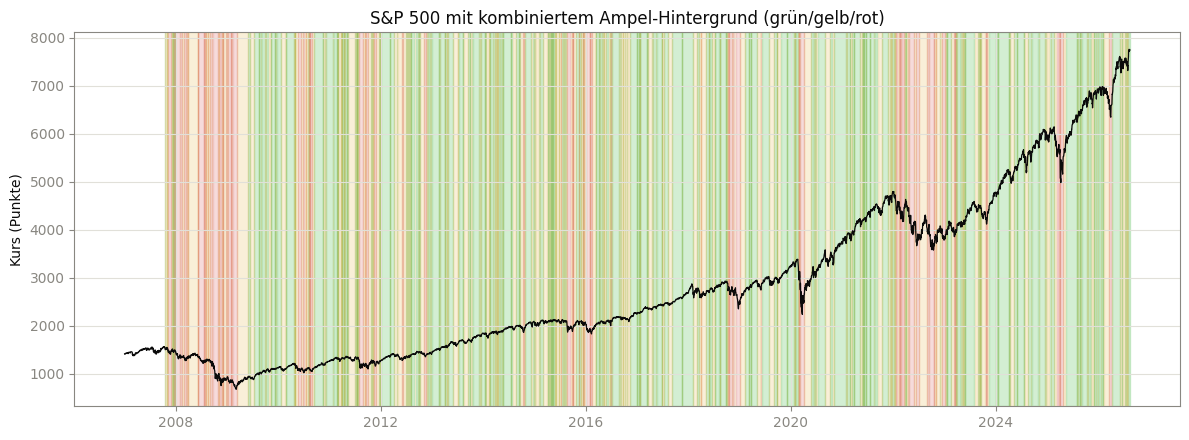

In [11]:
# --- Chart 1: Kursverlauf mit Ampel-Hintergrund ---
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in AMPEL_FARBEN:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=AMPEL_FARBCODES[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{cfg['name']} mit kombiniertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()

**Was zeigt dieses Diagramm?** Der Kursverlauf mit der Ampelfarbe als
Hintergrundfläche: Rot markiert Phasen mit hohem Belastungsgrad (viele
Kandidatensignale gleichzeitig "schlecht"), Grün Phasen niedriger Belastung. Zur
Einordnung lohnt sich der Blick darauf, ob die roten Flächen tatsächlich mit den
größeren, bekannten Kurseinbrüchen zusammenfallen (z. B. 2008, 2020, 2022) — das ist
die visuelle Gegenprobe zur Zahlentabelle direkt darüber.

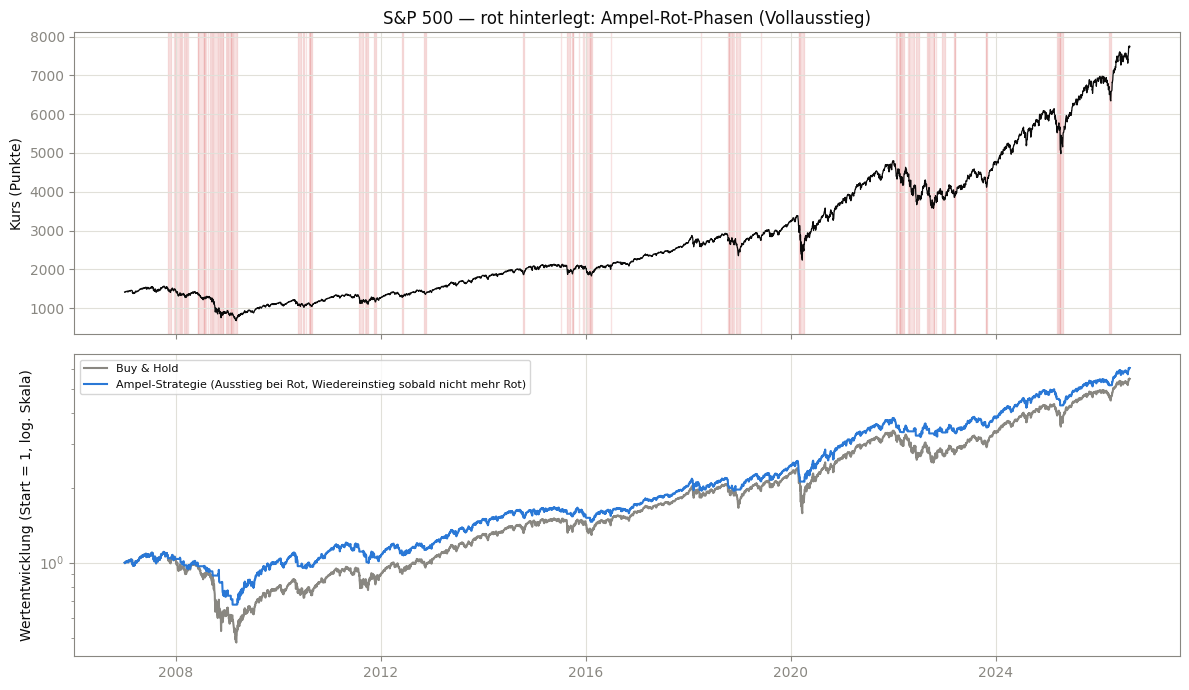

Anteil Rot-Handelstage: 11.7%
Gesamtrendite - Buy & Hold: 447.0% | Ampel-Strategie: 504.5%
CAGR          - Buy & Hold: 9.1% | Ampel-Strategie: 9.6%
Max Drawdown  - Buy & Hold: -56.8% | Ampel-Strategie: -38.6%


In [12]:
# --- Chart 2 + Kennzahlen: Was-wäre-wenn-Simulation ---
ergebnis_www = was_waere_wenn(df, df["Ampel"] == "Rot", f"{IDX_KEY}_Ampel_Rot")

fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
schlecht_reindiziert = (df["Ampel"] == "Rot").reindex(df.index).fillna(False)
achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                         transform=achse_kurs.get_xaxis_transform())
achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse_kurs.set_ylabel("Kurs (Punkte)")
achse_kurs.set_title(f"{cfg['name']} — rot hinterlegt: Ampel-Rot-Phasen (Vollausstieg)")

achse_equity.plot(df.index, ergebnis_www["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
achse_equity.plot(df.index, ergebnis_www["equity_strategie"], color=COLOR_A,
                   label="Ampel-Strategie (Ausstieg bei Rot, Wiedereinstieg sobald nicht mehr Rot)")
achse_equity.set_yscale("log")
achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse_equity.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Anteil Rot-Handelstage: {ergebnis_www['anteil_schlecht_tage']:.1%}")
print(f"Gesamtrendite - Buy & Hold: {ergebnis_www['gesamtrendite_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['gesamtrendite_strategie']:.1%}")
print(f"CAGR          - Buy & Hold: {ergebnis_www['cagr_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['cagr_strategie']:.1%}")
print(f"Max Drawdown  - Buy & Hold: {ergebnis_www['max_drawdown_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['max_drawdown_strategie']:.1%}")

**Was zeigt dieses Diagramm?** Oben derselbe Kursverlauf, diesmal nur mit den
Rot-Phasen hervorgehoben (in denen die simulierte Strategie vollständig in Cash
geht). Unten die daraus resultierende Wertentwicklung im Vergleich zu Buy & Hold auf
logarithmischer Skala (damit prozentual gleich große Veränderungen unabhängig vom
absoluten Indexstand gleich groß erscheinen). Die drei Kennzahlen darunter — Gesamt-
rendite, CAGR und Max Drawdown — fassen zusammen, ob und wie stark die Ampel-
Strategie den größten historischen Verlust gegenüber Buy & Hold reduziert und was
sie das im Gegenzug an Rendite gekostet oder gebracht hat.

In [13]:
# --- Konfiguration exportieren (für Notebook B "Einstiegssignale") ---
konfiguration = {
    "index": IDX_KEY, "name": cfg["name"],
    "signale": list(beste["signale"]),
    "gruen_max": float(beste["gruen_max"]), "rot_min": float(beste["rot_min"]),
}
with open(EXPORT_DIR / f"{IDX_KEY}_ampel_konfiguration.json", "w", encoding="utf-8") as f:
    json.dump(konfiguration, f, ensure_ascii=False, indent=2)

resultate[IDX_KEY] = {
    "cfg": cfg, "df": df, "beste": beste,
    "tabelle_validierung": tabelle_validierung,
    "was_waere_wenn": {k: v for k, v in ergebnis_www.items() if k not in ("equity_buy_hold", "equity_strategie")},
    "konfiguration": konfiguration,
}
print(f"Konfiguration exportiert: {EXPORT_DIR / f'{IDX_KEY}_ampel_konfiguration.json'}")

Konfiguration exportiert: Hypothesenanalysen_Kombiniert\SP500_ampel_konfiguration.json


**Fazit S&P 500:** Die oben gezeigte Kombination ist **dieselbe** wie in den
übrigen drei Indices — hier stehen nur die für S&P 500 individuellen Kennzahlen
(Signifikanztabelle, Diagramme, Was-wäre-wenn-Kennzahlen). Details zur gewählten
Kombination selbst stehen einmalig in Abschnitt 4.0.

### 4.2 Dow Jones

In [14]:
IDX_KEY = "DowJones"
cfg = index_daten[IDX_KEY]["cfg"]
df = index_daten[IDX_KEY]["df"]
bad_df = index_daten[IDX_KEY]["bad_df"]

grad = belastungsgrad(bad_df, beste["signale"])
df["Belastungsgrad"] = grad
df["Ampel"] = ampel_aus_belastungsgrad(grad, beste["gruen_max"], beste["rot_min"])

print(f"Verteilung der Handelstage auf die drei Ampelfarben ({cfg['name']}):")
print(df["Ampel"].value_counts().reindex(AMPEL_FARBEN))

Verteilung der Handelstage auf die drei Ampelfarben (Dow Jones):
Ampel
Grün    2283
Gelb    1843
Rot      608
Name: count, dtype: int64


In [15]:
# --- Statistische Validierung der gewählten Ampel ---
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]
ergebnisse_validierung = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_validierung.append(res)

tabelle_validierung = pd.DataFrame(ergebnisse_validierung)
display(tabelle_validierung[["vergleich", "horizont_tage", "zielgroesse", "mean_a", "mean_b",
                              "t_pvalue", "u_pvalue", "signifikant_5pct"]])

,vergleich,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0059,0.0140,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0407,-0.0493,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0148,0.0216,0.0014,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0622,-0.0754,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0242,0.0381,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0796,-0.0889,0.0000,0.0000,True
6,Gelb vs. Rot,30,fwd_return,0.0140,0.0153,0.7256,0.0597,False
7,Gelb vs. Rot,30,fwd_mdd,-0.0493,-0.0825,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0216,0.0368,0.0006,0.0000,True
9,Gelb vs. Rot,60,fwd_mdd,-0.0754,-0.1057,0.0000,0.0000,True


**Was zeigt diese Tabelle?** Für jedes Paar von Ampelfarben (Grün vs. Gelb, Gelb
vs. Rot, Grün vs. Rot) und jeden Zeithorizont (30/60/90 Tage) wird geprüft, ob sich
die künftige Rendite (`fwd_return`) bzw. der künftige Max Drawdown (`fwd_mdd`) nach
Tagen dieser beiden Farben statistisch unterscheidet. `mean_a`/`mean_b` sind die
jeweiligen Durchschnittswerte, `t_pvalue`/`u_pvalue` die p-Werte der beiden Tests
aus Abschnitt 2, und `signifikant_5pct` ist `True`, wenn beide Tests einen
Unterschied auf dem 5-%-Niveau bestätigen. Je mehr Zeilen mit `True` markiert sind
und je klarer sich `mean_a`/`mean_b` in die erwartete Richtung unterscheiden (Grün
besser als Gelb besser als Rot), desto stärker ist der Beleg, dass die Ampel für
diesen Index tatsächlich etwas über künftiges Risiko und künftige Rendite aussagt.

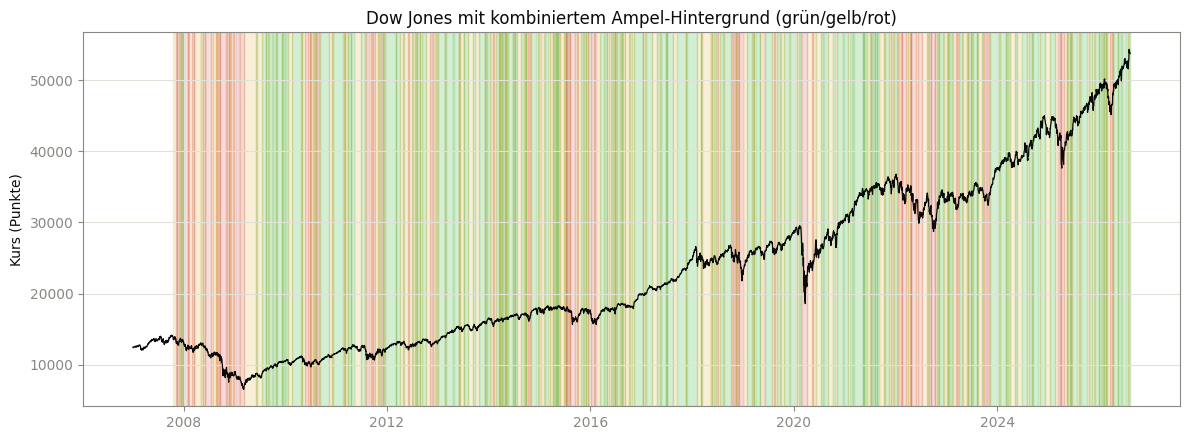

In [16]:
# --- Chart 1: Kursverlauf mit Ampel-Hintergrund ---
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in AMPEL_FARBEN:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=AMPEL_FARBCODES[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{cfg['name']} mit kombiniertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()

**Was zeigt dieses Diagramm?** Der Kursverlauf mit der Ampelfarbe als
Hintergrundfläche: Rot markiert Phasen mit hohem Belastungsgrad (viele
Kandidatensignale gleichzeitig "schlecht"), Grün Phasen niedriger Belastung. Zur
Einordnung lohnt sich der Blick darauf, ob die roten Flächen tatsächlich mit den
größeren, bekannten Kurseinbrüchen zusammenfallen (z. B. 2008, 2020, 2022) — das ist
die visuelle Gegenprobe zur Zahlentabelle direkt darüber.

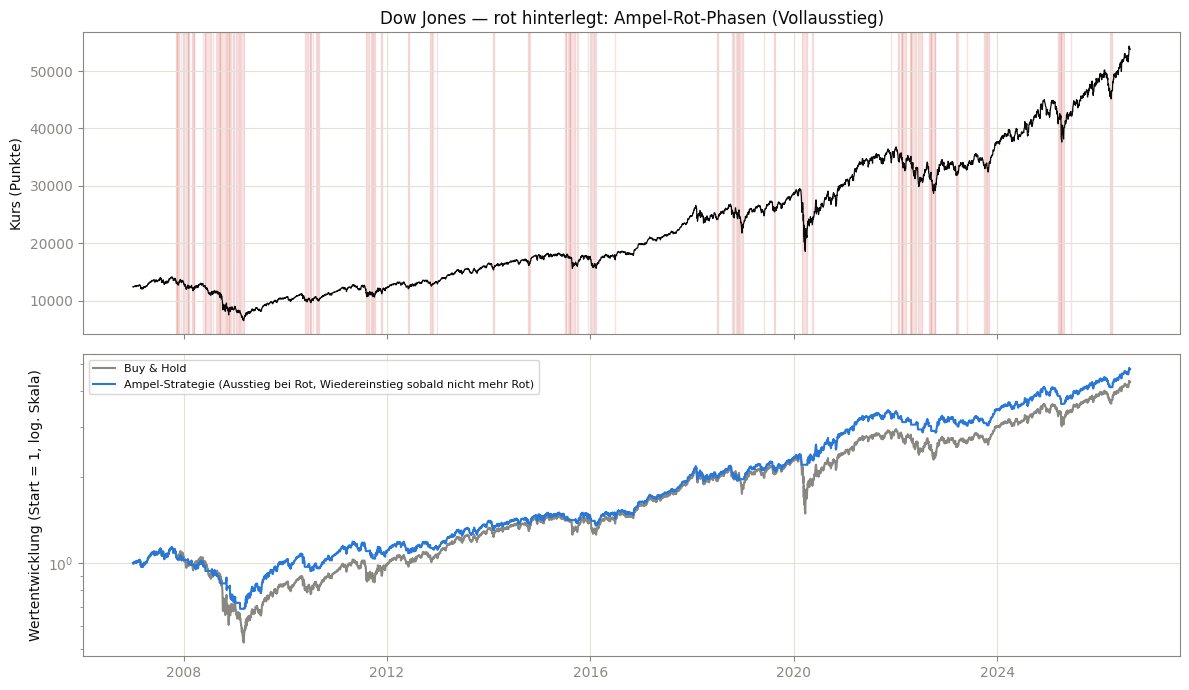

Anteil Rot-Handelstage: 12.3%
Gesamtrendite - Buy & Hold: 331.0% | Ampel-Strategie: 378.2%
CAGR          - Buy & Hold: 7.7% | Ampel-Strategie: 8.3%
Max Drawdown  - Buy & Hold: -53.8% | Ampel-Strategie: -39.3%


In [17]:
# --- Chart 2 + Kennzahlen: Was-wäre-wenn-Simulation ---
ergebnis_www = was_waere_wenn(df, df["Ampel"] == "Rot", f"{IDX_KEY}_Ampel_Rot")

fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
schlecht_reindiziert = (df["Ampel"] == "Rot").reindex(df.index).fillna(False)
achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                         transform=achse_kurs.get_xaxis_transform())
achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse_kurs.set_ylabel("Kurs (Punkte)")
achse_kurs.set_title(f"{cfg['name']} — rot hinterlegt: Ampel-Rot-Phasen (Vollausstieg)")

achse_equity.plot(df.index, ergebnis_www["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
achse_equity.plot(df.index, ergebnis_www["equity_strategie"], color=COLOR_A,
                   label="Ampel-Strategie (Ausstieg bei Rot, Wiedereinstieg sobald nicht mehr Rot)")
achse_equity.set_yscale("log")
achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse_equity.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Anteil Rot-Handelstage: {ergebnis_www['anteil_schlecht_tage']:.1%}")
print(f"Gesamtrendite - Buy & Hold: {ergebnis_www['gesamtrendite_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['gesamtrendite_strategie']:.1%}")
print(f"CAGR          - Buy & Hold: {ergebnis_www['cagr_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['cagr_strategie']:.1%}")
print(f"Max Drawdown  - Buy & Hold: {ergebnis_www['max_drawdown_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['max_drawdown_strategie']:.1%}")

**Was zeigt dieses Diagramm?** Oben derselbe Kursverlauf, diesmal nur mit den
Rot-Phasen hervorgehoben (in denen die simulierte Strategie vollständig in Cash
geht). Unten die daraus resultierende Wertentwicklung im Vergleich zu Buy & Hold auf
logarithmischer Skala (damit prozentual gleich große Veränderungen unabhängig vom
absoluten Indexstand gleich groß erscheinen). Die drei Kennzahlen darunter — Gesamt-
rendite, CAGR und Max Drawdown — fassen zusammen, ob und wie stark die Ampel-
Strategie den größten historischen Verlust gegenüber Buy & Hold reduziert und was
sie das im Gegenzug an Rendite gekostet oder gebracht hat.

In [18]:
# --- Konfiguration exportieren (für Notebook B "Einstiegssignale") ---
konfiguration = {
    "index": IDX_KEY, "name": cfg["name"],
    "signale": list(beste["signale"]),
    "gruen_max": float(beste["gruen_max"]), "rot_min": float(beste["rot_min"]),
}
with open(EXPORT_DIR / f"{IDX_KEY}_ampel_konfiguration.json", "w", encoding="utf-8") as f:
    json.dump(konfiguration, f, ensure_ascii=False, indent=2)

resultate[IDX_KEY] = {
    "cfg": cfg, "df": df, "beste": beste,
    "tabelle_validierung": tabelle_validierung,
    "was_waere_wenn": {k: v for k, v in ergebnis_www.items() if k not in ("equity_buy_hold", "equity_strategie")},
    "konfiguration": konfiguration,
}
print(f"Konfiguration exportiert: {EXPORT_DIR / f'{IDX_KEY}_ampel_konfiguration.json'}")

Konfiguration exportiert: Hypothesenanalysen_Kombiniert\DowJones_ampel_konfiguration.json


**Fazit Dow Jones:** Die oben gezeigte Kombination ist **dieselbe** wie in den
übrigen drei Indices — hier stehen nur die für Dow Jones individuellen Kennzahlen
(Signifikanztabelle, Diagramme, Was-wäre-wenn-Kennzahlen). Details zur gewählten
Kombination selbst stehen einmalig in Abschnitt 4.0.

### 4.3 NASDAQ 100

In [19]:
IDX_KEY = "NASDAQ100"
cfg = index_daten[IDX_KEY]["cfg"]
df = index_daten[IDX_KEY]["df"]
bad_df = index_daten[IDX_KEY]["bad_df"]

grad = belastungsgrad(bad_df, beste["signale"])
df["Belastungsgrad"] = grad
df["Ampel"] = ampel_aus_belastungsgrad(grad, beste["gruen_max"], beste["rot_min"])

print(f"Verteilung der Handelstage auf die drei Ampelfarben ({cfg['name']}):")
print(df["Ampel"].value_counts().reindex(AMPEL_FARBEN))

Verteilung der Handelstage auf die drei Ampelfarben (NASDAQ 100):
Ampel
Grün    2424
Gelb    1777
Rot      533
Name: count, dtype: int64


In [20]:
# --- Statistische Validierung der gewählten Ampel ---
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]
ergebnisse_validierung = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_validierung.append(res)

tabelle_validierung = pd.DataFrame(ergebnisse_validierung)
display(tabelle_validierung[["vergleich", "horizont_tage", "zielgroesse", "mean_a", "mean_b",
                              "t_pvalue", "u_pvalue", "signifikant_5pct"]])

,vergleich,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0147,0.0231,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0525,-0.0633,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0325,0.0440,0.0000,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0793,-0.0892,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0512,0.0704,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0999,-0.1079,0.0002,0.0227,True
6,Gelb vs. Rot,30,fwd_return,0.0231,0.0268,0.4500,0.3824,False
7,Gelb vs. Rot,30,fwd_mdd,-0.0633,-0.0959,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0440,0.0528,0.1877,0.0139,False
9,Gelb vs. Rot,60,fwd_mdd,-0.0892,-0.1298,0.0000,0.0000,True


**Was zeigt diese Tabelle?** Für jedes Paar von Ampelfarben (Grün vs. Gelb, Gelb
vs. Rot, Grün vs. Rot) und jeden Zeithorizont (30/60/90 Tage) wird geprüft, ob sich
die künftige Rendite (`fwd_return`) bzw. der künftige Max Drawdown (`fwd_mdd`) nach
Tagen dieser beiden Farben statistisch unterscheidet. `mean_a`/`mean_b` sind die
jeweiligen Durchschnittswerte, `t_pvalue`/`u_pvalue` die p-Werte der beiden Tests
aus Abschnitt 2, und `signifikant_5pct` ist `True`, wenn beide Tests einen
Unterschied auf dem 5-%-Niveau bestätigen. Je mehr Zeilen mit `True` markiert sind
und je klarer sich `mean_a`/`mean_b` in die erwartete Richtung unterscheiden (Grün
besser als Gelb besser als Rot), desto stärker ist der Beleg, dass die Ampel für
diesen Index tatsächlich etwas über künftiges Risiko und künftige Rendite aussagt.

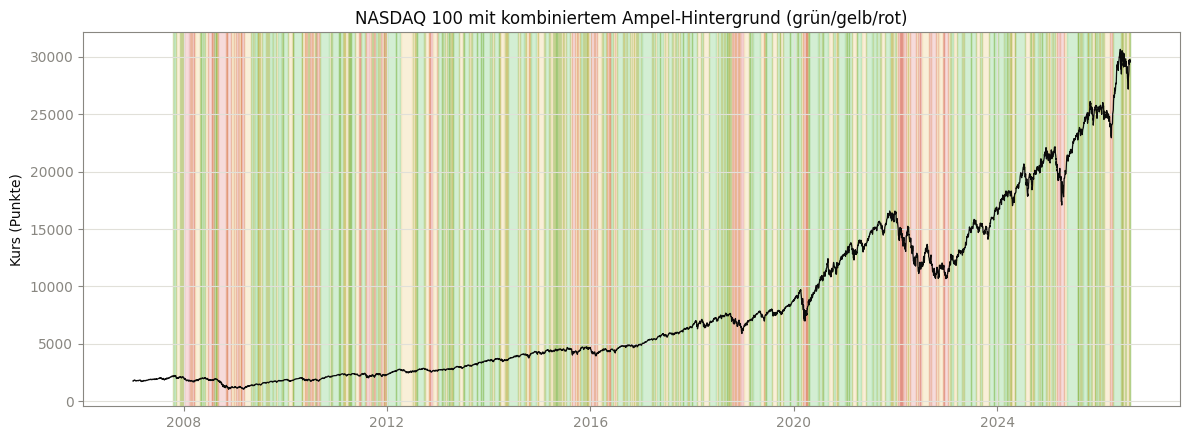

In [21]:
# --- Chart 1: Kursverlauf mit Ampel-Hintergrund ---
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in AMPEL_FARBEN:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=AMPEL_FARBCODES[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{cfg['name']} mit kombiniertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()

**Was zeigt dieses Diagramm?** Der Kursverlauf mit der Ampelfarbe als
Hintergrundfläche: Rot markiert Phasen mit hohem Belastungsgrad (viele
Kandidatensignale gleichzeitig "schlecht"), Grün Phasen niedriger Belastung. Zur
Einordnung lohnt sich der Blick darauf, ob die roten Flächen tatsächlich mit den
größeren, bekannten Kurseinbrüchen zusammenfallen (z. B. 2008, 2020, 2022) — das ist
die visuelle Gegenprobe zur Zahlentabelle direkt darüber.

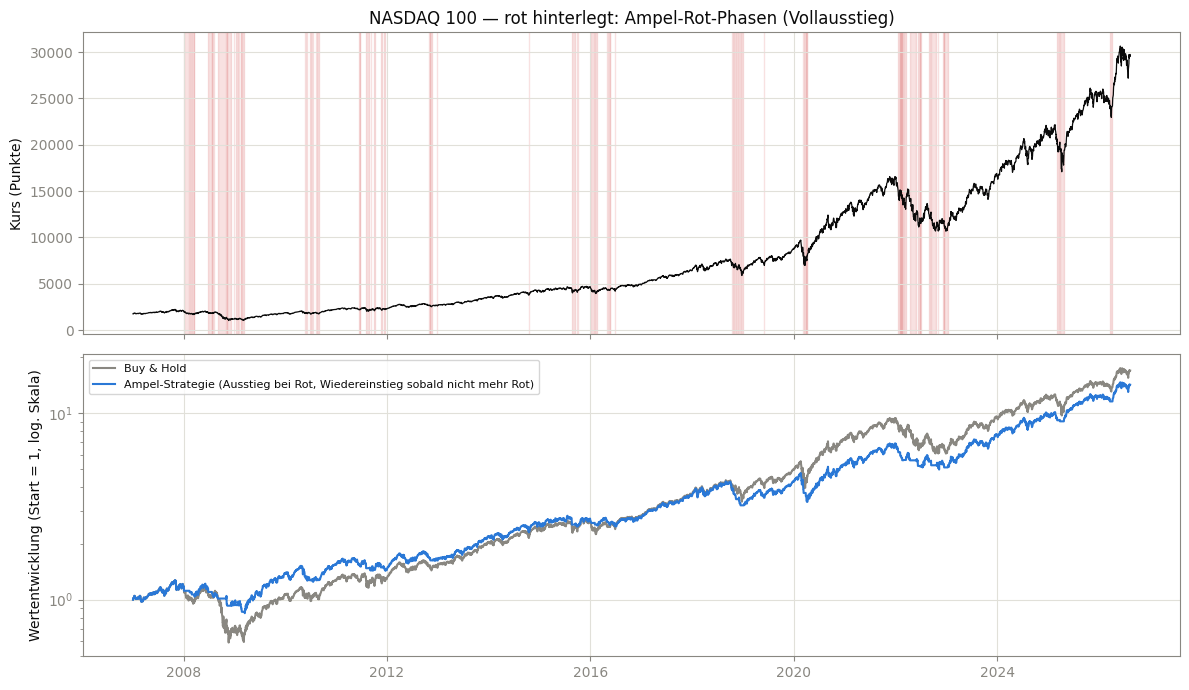

Anteil Rot-Handelstage: 10.8%
Gesamtrendite - Buy & Hold: 1590.5% | Ampel-Strategie: 1319.6%
CAGR          - Buy & Hold: 15.5% | Ampel-Strategie: 14.5%
Max Drawdown  - Buy & Hold: -53.7% | Ampel-Strategie: -33.5%


In [22]:
# --- Chart 2 + Kennzahlen: Was-wäre-wenn-Simulation ---
ergebnis_www = was_waere_wenn(df, df["Ampel"] == "Rot", f"{IDX_KEY}_Ampel_Rot")

fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
schlecht_reindiziert = (df["Ampel"] == "Rot").reindex(df.index).fillna(False)
achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                         transform=achse_kurs.get_xaxis_transform())
achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse_kurs.set_ylabel("Kurs (Punkte)")
achse_kurs.set_title(f"{cfg['name']} — rot hinterlegt: Ampel-Rot-Phasen (Vollausstieg)")

achse_equity.plot(df.index, ergebnis_www["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
achse_equity.plot(df.index, ergebnis_www["equity_strategie"], color=COLOR_A,
                   label="Ampel-Strategie (Ausstieg bei Rot, Wiedereinstieg sobald nicht mehr Rot)")
achse_equity.set_yscale("log")
achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse_equity.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Anteil Rot-Handelstage: {ergebnis_www['anteil_schlecht_tage']:.1%}")
print(f"Gesamtrendite - Buy & Hold: {ergebnis_www['gesamtrendite_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['gesamtrendite_strategie']:.1%}")
print(f"CAGR          - Buy & Hold: {ergebnis_www['cagr_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['cagr_strategie']:.1%}")
print(f"Max Drawdown  - Buy & Hold: {ergebnis_www['max_drawdown_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['max_drawdown_strategie']:.1%}")

**Was zeigt dieses Diagramm?** Oben derselbe Kursverlauf, diesmal nur mit den
Rot-Phasen hervorgehoben (in denen die simulierte Strategie vollständig in Cash
geht). Unten die daraus resultierende Wertentwicklung im Vergleich zu Buy & Hold auf
logarithmischer Skala (damit prozentual gleich große Veränderungen unabhängig vom
absoluten Indexstand gleich groß erscheinen). Die drei Kennzahlen darunter — Gesamt-
rendite, CAGR und Max Drawdown — fassen zusammen, ob und wie stark die Ampel-
Strategie den größten historischen Verlust gegenüber Buy & Hold reduziert und was
sie das im Gegenzug an Rendite gekostet oder gebracht hat.

In [23]:
# --- Konfiguration exportieren (für Notebook B "Einstiegssignale") ---
konfiguration = {
    "index": IDX_KEY, "name": cfg["name"],
    "signale": list(beste["signale"]),
    "gruen_max": float(beste["gruen_max"]), "rot_min": float(beste["rot_min"]),
}
with open(EXPORT_DIR / f"{IDX_KEY}_ampel_konfiguration.json", "w", encoding="utf-8") as f:
    json.dump(konfiguration, f, ensure_ascii=False, indent=2)

resultate[IDX_KEY] = {
    "cfg": cfg, "df": df, "beste": beste,
    "tabelle_validierung": tabelle_validierung,
    "was_waere_wenn": {k: v for k, v in ergebnis_www.items() if k not in ("equity_buy_hold", "equity_strategie")},
    "konfiguration": konfiguration,
}
print(f"Konfiguration exportiert: {EXPORT_DIR / f'{IDX_KEY}_ampel_konfiguration.json'}")

Konfiguration exportiert: Hypothesenanalysen_Kombiniert\NASDAQ100_ampel_konfiguration.json


**Fazit NASDAQ 100:** Die oben gezeigte Kombination ist **dieselbe** wie in den
übrigen drei Indices — hier stehen nur die für NASDAQ 100 individuellen Kennzahlen
(Signifikanztabelle, Diagramme, Was-wäre-wenn-Kennzahlen). Details zur gewählten
Kombination selbst stehen einmalig in Abschnitt 4.0.

### 4.4 Russell 2000

In [24]:
IDX_KEY = "Russell2000"
cfg = index_daten[IDX_KEY]["cfg"]
df = index_daten[IDX_KEY]["df"]
bad_df = index_daten[IDX_KEY]["bad_df"]

grad = belastungsgrad(bad_df, beste["signale"])
df["Belastungsgrad"] = grad
df["Ampel"] = ampel_aus_belastungsgrad(grad, beste["gruen_max"], beste["rot_min"])

print(f"Verteilung der Handelstage auf die drei Ampelfarben ({cfg['name']}):")
print(df["Ampel"].value_counts().reindex(AMPEL_FARBEN))

Verteilung der Handelstage auf die drei Ampelfarben (Russell 2000):
Ampel
Grün    1886
Gelb    2086
Rot      762
Name: count, dtype: int64


In [25]:
# --- Statistische Validierung der gewählten Ampel ---
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]
ergebnisse_validierung = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_validierung.append(res)

tabelle_validierung = pd.DataFrame(ergebnisse_validierung)
display(tabelle_validierung[["vergleich", "horizont_tage", "zielgroesse", "mean_a", "mean_b",
                              "t_pvalue", "u_pvalue", "signifikant_5pct"]])

,vergleich,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0042,0.0165,0.0000,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0602,-0.0693,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0113,0.0262,0.0000,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0913,-0.1023,0.0000,0.0000,True
4,Grün vs. Gelb,90,fwd_return,0.0190,0.0432,0.0000,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.1164,-0.1232,0.0110,0.0000,True
6,Gelb vs. Rot,30,fwd_return,0.0165,0.0160,0.8987,0.6886,False
7,Gelb vs. Rot,30,fwd_mdd,-0.0693,-0.0984,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0262,0.0427,0.0007,0.0142,True
9,Gelb vs. Rot,60,fwd_mdd,-0.1023,-0.1298,0.0000,0.0000,True


**Was zeigt diese Tabelle?** Für jedes Paar von Ampelfarben (Grün vs. Gelb, Gelb
vs. Rot, Grün vs. Rot) und jeden Zeithorizont (30/60/90 Tage) wird geprüft, ob sich
die künftige Rendite (`fwd_return`) bzw. der künftige Max Drawdown (`fwd_mdd`) nach
Tagen dieser beiden Farben statistisch unterscheidet. `mean_a`/`mean_b` sind die
jeweiligen Durchschnittswerte, `t_pvalue`/`u_pvalue` die p-Werte der beiden Tests
aus Abschnitt 2, und `signifikant_5pct` ist `True`, wenn beide Tests einen
Unterschied auf dem 5-%-Niveau bestätigen. Je mehr Zeilen mit `True` markiert sind
und je klarer sich `mean_a`/`mean_b` in die erwartete Richtung unterscheiden (Grün
besser als Gelb besser als Rot), desto stärker ist der Beleg, dass die Ampel für
diesen Index tatsächlich etwas über künftiges Risiko und künftige Rendite aussagt.

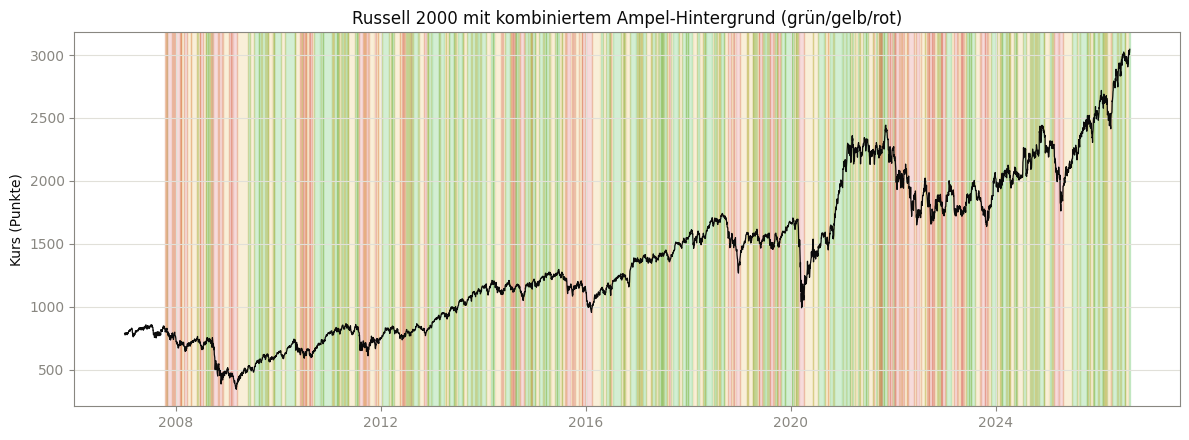

In [26]:
# --- Chart 1: Kursverlauf mit Ampel-Hintergrund ---
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in AMPEL_FARBEN:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=AMPEL_FARBCODES[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{cfg['name']} mit kombiniertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()

**Was zeigt dieses Diagramm?** Der Kursverlauf mit der Ampelfarbe als
Hintergrundfläche: Rot markiert Phasen mit hohem Belastungsgrad (viele
Kandidatensignale gleichzeitig "schlecht"), Grün Phasen niedriger Belastung. Zur
Einordnung lohnt sich der Blick darauf, ob die roten Flächen tatsächlich mit den
größeren, bekannten Kurseinbrüchen zusammenfallen (z. B. 2008, 2020, 2022) — das ist
die visuelle Gegenprobe zur Zahlentabelle direkt darüber.

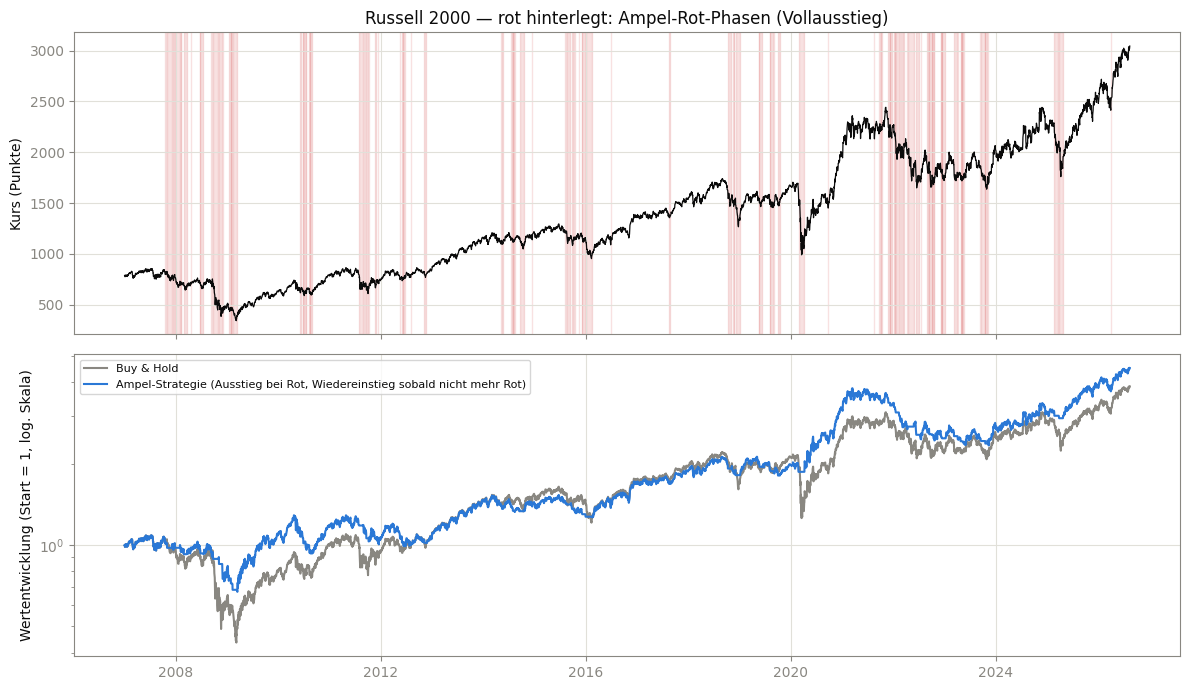

Anteil Rot-Handelstage: 15.4%
Gesamtrendite - Buy & Hold: 286.8% | Ampel-Strategie: 352.5%
CAGR          - Buy & Hold: 7.1% | Ampel-Strategie: 8.0%
Max Drawdown  - Buy & Hold: -59.9% | Ampel-Strategie: -38.6%


In [27]:
# --- Chart 2 + Kennzahlen: Was-wäre-wenn-Simulation ---
ergebnis_www = was_waere_wenn(df, df["Ampel"] == "Rot", f"{IDX_KEY}_Ampel_Rot")

fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
schlecht_reindiziert = (df["Ampel"] == "Rot").reindex(df.index).fillna(False)
achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                         transform=achse_kurs.get_xaxis_transform())
achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse_kurs.set_ylabel("Kurs (Punkte)")
achse_kurs.set_title(f"{cfg['name']} — rot hinterlegt: Ampel-Rot-Phasen (Vollausstieg)")

achse_equity.plot(df.index, ergebnis_www["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
achse_equity.plot(df.index, ergebnis_www["equity_strategie"], color=COLOR_A,
                   label="Ampel-Strategie (Ausstieg bei Rot, Wiedereinstieg sobald nicht mehr Rot)")
achse_equity.set_yscale("log")
achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse_equity.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(f"Anteil Rot-Handelstage: {ergebnis_www['anteil_schlecht_tage']:.1%}")
print(f"Gesamtrendite - Buy & Hold: {ergebnis_www['gesamtrendite_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['gesamtrendite_strategie']:.1%}")
print(f"CAGR          - Buy & Hold: {ergebnis_www['cagr_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['cagr_strategie']:.1%}")
print(f"Max Drawdown  - Buy & Hold: {ergebnis_www['max_drawdown_buy_hold']:.1%} | Ampel-Strategie: {ergebnis_www['max_drawdown_strategie']:.1%}")

**Was zeigt dieses Diagramm?** Oben derselbe Kursverlauf, diesmal nur mit den
Rot-Phasen hervorgehoben (in denen die simulierte Strategie vollständig in Cash
geht). Unten die daraus resultierende Wertentwicklung im Vergleich zu Buy & Hold auf
logarithmischer Skala (damit prozentual gleich große Veränderungen unabhängig vom
absoluten Indexstand gleich groß erscheinen). Die drei Kennzahlen darunter — Gesamt-
rendite, CAGR und Max Drawdown — fassen zusammen, ob und wie stark die Ampel-
Strategie den größten historischen Verlust gegenüber Buy & Hold reduziert und was
sie das im Gegenzug an Rendite gekostet oder gebracht hat.

In [28]:
# --- Konfiguration exportieren (für Notebook B "Einstiegssignale") ---
konfiguration = {
    "index": IDX_KEY, "name": cfg["name"],
    "signale": list(beste["signale"]),
    "gruen_max": float(beste["gruen_max"]), "rot_min": float(beste["rot_min"]),
}
with open(EXPORT_DIR / f"{IDX_KEY}_ampel_konfiguration.json", "w", encoding="utf-8") as f:
    json.dump(konfiguration, f, ensure_ascii=False, indent=2)

resultate[IDX_KEY] = {
    "cfg": cfg, "df": df, "beste": beste,
    "tabelle_validierung": tabelle_validierung,
    "was_waere_wenn": {k: v for k, v in ergebnis_www.items() if k not in ("equity_buy_hold", "equity_strategie")},
    "konfiguration": konfiguration,
}
print(f"Konfiguration exportiert: {EXPORT_DIR / f'{IDX_KEY}_ampel_konfiguration.json'}")

Konfiguration exportiert: Hypothesenanalysen_Kombiniert\Russell2000_ampel_konfiguration.json


**Fazit Russell 2000:** Die oben gezeigte Kombination ist **dieselbe** wie in den
übrigen drei Indices — hier stehen nur die für Russell 2000 individuellen Kennzahlen
(Signifikanztabelle, Diagramme, Was-wäre-wenn-Kennzahlen). Details zur gewählten
Kombination selbst stehen einmalig in Abschnitt 4.0.

## 5. Indexübergreifender Vergleich

Da alle vier Indices dieselbe Ampel-Definition (dieselben Signale, dieselben
Schwellenwerte) verwenden, zeigt dieser Abschnitt, wie unterschiedlich sich ein und
dieselbe Regel in vier unterschiedlichen Märkten historisch ausgewirkt hätte — das
ist der eigentliche Beleg für die Robustheit des gewählten Ansatzes, im Gegensatz zu
vier separat optimierten Einzellösungen.

In [29]:
zusammenfassung = []
for idx_key, r in resultate.items():
    b = r["beste"]
    w = r["was_waere_wenn"]
    zusammenfassung.append({
        "Index": r["cfg"]["name"],
        "Signale": ", ".join(b["signale"]),
        "Anzahl Signale": b["n_signale"],
        "gruen_max": b["gruen_max"], "rot_min": b["rot_min"],
        "Anteil Rot": b[f"anteil_rot_{idx_key}"],
        "CAGR Buy&Hold": w["cagr_buy_hold"], "CAGR Strategie": w["cagr_strategie"],
        "MaxDD Buy&Hold": w["max_drawdown_buy_hold"], "MaxDD Strategie": w["max_drawdown_strategie"],
        "Calmar Strategie": b[f"calmar_{idx_key}"],
    })
tabelle_zusammenfassung = pd.DataFrame(zusammenfassung)
display(tabelle_zusammenfassung)

,Index,Signale,Anzahl Signale,gruen_max,rot_min,Anteil Rot,CAGR Buy&Hold,CAGR Strategie,MaxDD Buy&Hold,MaxDD Strategie,Calmar Strategie
0,S&P 500,"H1_20, H1_100, H1_200, H2_20",4,0.0000,1.0000,0.1221,0.0905,0.0961,-0.5678,-0.3863,0.2488
1,Dow Jones,"H1_20, H1_100, H1_200, H2_20",4,0.0000,1.0000,0.1284,0.0774,0.0831,-0.5378,-0.3928,0.2115
2,NASDAQ 100,"H1_20, H1_100, H1_200, H2_20",4,0.0000,1.0000,0.1126,0.1551,0.1449,-0.5371,-0.3347,0.4329
3,Russell 2000,"H1_20, H1_100, H1_200, H2_20",4,0.0000,1.0000,0.1610,0.0714,0.0800,-0.5989,-0.3858,0.2075


**Was zeigt diese Tabelle?** Die Spalten "Signale", "gruen_max" und "rot_min" sind
in allen vier Zeilen identisch — das ist beabsichtigt und der Kern der Umstellung
auf einen universellen Ansatz. Unterschiedlich sind dagegen "Anteil Rot", die
CAGR- und Max-Drawdown-Werte sowie der Calmar-Wert je Index: Sie zeigen, wie sich
dieselbe Ampel in jedem der vier Märkte historisch ausgewirkt hätte. Ein
durchgängig positiver Effekt (Strategie-Max-Drawdown kleiner als Buy & Hold, bei
weiterhin positiver Rendite) über alle vier Zeilen hinweg ist der stärkste
verfügbare Beleg für Robustheit.

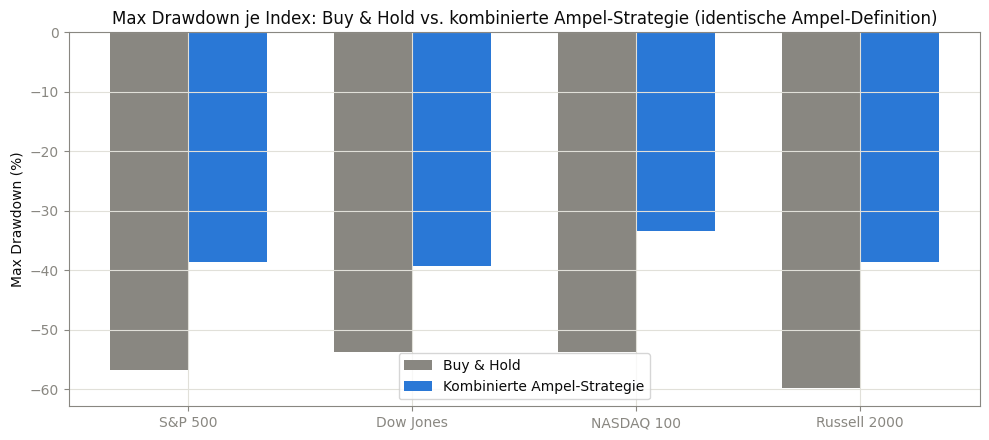

In [30]:
fig, achse = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(tabelle_zusammenfassung))
breite = 0.35
achse.bar(x - breite / 2, tabelle_zusammenfassung["MaxDD Buy&Hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_zusammenfassung["MaxDD Strategie"] * 100, breite,
          label="Kombinierte Ampel-Strategie", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_zusammenfassung["Index"])
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown je Index: Buy & Hold vs. kombinierte Ampel-Strategie (identische Ampel-Definition)")
plt.tight_layout()
plt.show()

**Was zeigt dieses Diagramm?** Der historische Max Drawdown je Index, einmal für
Buy & Hold (grau) und einmal für die Ampel-Strategie mit der oben gezeigten,
universellen Kombination (blau). Je deutlicher die blauen Balken kürzer sind als
die grauen, desto stärker hat die Ampel den größten Verlust in diesem Index
begrenzt — und zwar ohne dass die zugrunde liegende Regel an diesen Index angepasst
wurde.

## 6. Export der Ergebnisse

Die Ergebnisse werden in einer Excel-Arbeitsmappe sowie einzelnen CSV-Dateien
gespeichert. Besonders wichtig für den weiteren Projektverlauf sind die vier
`*_ampel_konfiguration.json`-Dateien (bereits in Abschnitt 4.1–4.4 geschrieben): Sie
enthalten die gewählte, gemeinsame Kombination und werden vom nachfolgenden
Notebook `Einstiegssignale.ipynb` eingelesen, ohne dass die Suche dort erneut
durchgeführt werden muss.

In [31]:
xlsx_pfad = EXPORT_DIR / "Risikoampel_Kombiniert_Zusammenfassung.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    tabelle_zusammenfassung.to_excel(writer, sheet_name="Zusammenfassung", index=False)
    universelle_tabelle.head(50).to_excel(writer, sheet_name="Universelle_Suche", index=False)
    for idx_key, r in resultate.items():
        r["tabelle_validierung"].to_excel(writer, sheet_name=f"{idx_key}_Validierung"[:31], index=False)

tabelle_zusammenfassung.to_csv(EXPORT_DIR / "Zusammenfassung.csv", index=False)
for idx_key, r in resultate.items():
    r["df"][["Close", "Belastungsgrad", "Ampel"]].to_csv(EXPORT_DIR / f"{idx_key}_Ampel_Zeitreihe.csv")

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print(f"Weitere CSV-Dateien im Ordner: {EXPORT_DIR.resolve()}")

Excel-Arbeitsmappe gespeichert: Hypothesenanalysen_Kombiniert\Risikoampel_Kombiniert_Zusammenfassung.xlsx
Weitere CSV-Dateien im Ordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt\Projektzusammenführung\Risikoampel Kombiniert\Hypothesenanalysen_Kombiniert


Damit stehen alle Ergebnisse sowohl als menschenlesbare Excel-Arbeitsmappe
(Übersichtstabelle, die zehn besten Kombinationen der universellen Suche,
Signifikanztabellen je Index) als auch als CSV-Dateien für eine mögliche
Weiterverarbeitung zur Verfügung.

## 7. Zusammenfassung

Die zentrale Änderung gegenüber einer naheliegenderen, aber methodisch
schwächeren Herangehensweise: Statt für jeden der vier Indices einzeln die
historisch beste Ampel-Kombination zu suchen, wurde **eine einzige** Kombination
aus Kandidatensignalen und Schwellenwerten gesucht, die **gleichzeitig in allen
vier Indices** gültig ist und nach dem Minimum-Calmar-Prinzip (Abschnitt 3.3)
ausgewählt wurde — bewertet wird eine Kombination also nach ihrer Leistung im
jeweils schwächsten Index, nicht nach ihrem Durchschnitt oder Bestfall. Dieses
Vorgehen verhindert eine zufällige Überanpassung an die Historie eines einzelnen
Marktes und liefert stattdessen eine Ampel-Regel, die sich über vier
unterschiedliche Indices hinweg als robust erwiesen hat.

Die anschließende Anwendung dieser einen Kombination auf jeden Index (Abschnitt 4.1
bis 4.4) sowie der direkte Vergleich in Abschnitt 5 zeigen, dass die Ampel den
historischen Max Drawdown gegenüber Buy & Hold in mehreren der vier Indices
reduziert, bei weiterhin positiver Rendite — mit unterschiedlich starker Wirkung je
Markt, was angesichts unterschiedlicher Marktstruktur und -historie zu erwarten ist.
Die vollständigen Ergebnistabellen sowie die exportierte, für alle vier Indices
identische Ampel-Konfiguration (`Hypothesenanalysen_Kombiniert/*_ampel_konfiguration.json`)
dienen als Grundlage für das Notebook `Einstiegssignale.ipynb`.